# 04 - Classification Naive Bayes

**Objectif** : entraîner un pipeline TF-IDF + Multinomial Naive Bayes pour prédire le label Urgent/Normal
construit au notebook 03, évaluer sa robustesse par validation croisée 5-fold, et comparer les résultats
au système Regex via l'annotation humaine du notebook 05.

**Choix de gestion du déséquilibre** : le dataset est déséquilibré (~5% Urgent / ~95% Normal).
MultinomialNB n'a pas de paramètre `class_weight` natif — l'équivalent consiste à passer un
`sample_weight` équilibré calculé avec `compute_sample_weight("balanced", y_train)` à la méthode `.fit()`.

## 0. Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    PrecisionRecallDisplay,
    average_precision_score,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../data/drugs_labeled.csv")
print(df.shape)
df["label"].value_counts()

(139039, 3)


label
Normal    131818
Urgent      7221
Name: count, dtype: int64

## 1. Pipeline TF-IDF + MultinomialNB avec validation croisée 5-fold

Pour chaque fold :
- Le TfidfVectorizer est ajusté uniquement sur le train du fold (pas de fuite vers le test)
- Un `sample_weight` équilibré est calculé sur `y_train`
- MultinomialNB est entraîné avec ce poids
- Les prédictions de chaque fold sont assemblées en prédictions out-of-fold

In [22]:
X_text = df["review_clean"].astype(str).values
y      = df["label"].values

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_pred = np.empty(len(y), dtype=object)
oof_prob = np.zeros(len(y))   # probabilités out-of-fold pour la courbe PR
fold_metrics = []

# Sauvegarder le dernier vectorizer et modèle pour la section 6
last_vectorizer = None
last_nb         = None

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_text, y), start=1):
    X_train, X_test = X_text[train_idx], X_text[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf  = vectorizer.transform(X_test)

    sample_weight = compute_sample_weight("balanced", y_train)

    nb = MultinomialNB(alpha=1.0)
    nb.fit(X_train_tfidf, y_train, sample_weight=sample_weight)

    y_pred = nb.predict(X_test_tfidf)
    y_prob = nb.predict_proba(X_test_tfidf)

    # Probabilité de la classe Urgent
    urgent_idx = list(nb.classes_).index("Urgent")
    oof_pred[test_idx] = y_pred
    oof_prob[test_idx] = y_prob[:, urgent_idx]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=["Urgent","Normal"], zero_division=0
    )
    fold_metrics.append({
        "fold"              : fold_idx,
        "precision_urgent"  : precision[0],
        "recall_urgent"     : recall[0],
        "f1_urgent"         : f1[0],
        "precision_normal"  : precision[1],
        "recall_normal"     : recall[1],
        "f1_normal"         : f1[1],
    })
    print(f"Fold {fold_idx} | Rappel Urgent: {recall[0]:.3f} | "
          f"Precision Urgent: {precision[0]:.3f} | F1 Urgent: {f1[0]:.3f}")

    last_vectorizer = vectorizer
    last_nb         = nb

Fold 1 | Rappel Urgent: 0.949 | Precision Urgent: 0.453 | F1 Urgent: 0.614
Fold 2 | Rappel Urgent: 0.948 | Precision Urgent: 0.443 | F1 Urgent: 0.604
Fold 3 | Rappel Urgent: 0.948 | Precision Urgent: 0.452 | F1 Urgent: 0.612
Fold 4 | Rappel Urgent: 0.949 | Precision Urgent: 0.454 | F1 Urgent: 0.614
Fold 5 | Rappel Urgent: 0.954 | Precision Urgent: 0.470 | F1 Urgent: 0.629


## 2. Robustesse de la validation croisée (moyenne +/- écart-type)

In [23]:
fold_df = pd.DataFrame(fold_metrics).set_index("fold")
print(fold_df.round(4))
print()
summary_cv = fold_df.agg(["mean","std"]).T
summary_cv.columns = ["mean","std"]
print("Résumé :")
print(summary_cv.round(4))

      precision_urgent  recall_urgent  f1_urgent  precision_normal  \
fold                                                                 
1               0.4533         0.9488     0.6135            0.9970   
2               0.4429         0.9481     0.6037            0.9970   
3               0.4517         0.9481     0.6118            0.9970   
4               0.4542         0.9495     0.6144            0.9971   
5               0.4698         0.9536     0.6295            0.9973   

      recall_normal  f1_normal  
fold                            
1            0.9373     0.9663  
2            0.9347     0.9648  
3            0.9370     0.9660  
4            0.9375     0.9663  
5            0.9411     0.9684  

Résumé :
                    mean     std
precision_urgent  0.4544  0.0097
recall_urgent     0.9496  0.0023
f1_urgent         0.6146  0.0093
precision_normal  0.9971  0.0001
recall_normal     0.9375  0.0023
f1_normal         0.9664  0.0013


## 3. Métriques agrégées out-of-fold (139 039 lignes)

In [24]:
print(classification_report(y, oof_pred, labels=["Urgent","Normal"], digits=3))

precision, recall, f1, support = precision_recall_fscore_support(
    y, oof_pred, labels=["Urgent","Normal"], zero_division=0
)
metrics_table = pd.DataFrame({
    "precision" : precision,
    "recall"    : recall,
    "f1"        : f1,
    "support"   : support,
}, index=["Urgent","Normal"])
print(metrics_table.round(4))

# Vérification seuil clinique
recall_urgent_oof = recall[0]
SEUIL_CLINIQUE    = 0.60
if recall_urgent_oof < SEUIL_CLINIQUE:
    print(f"ATTENTION : Rappel Urgent ({recall_urgent_oof:.3f}) < {SEUIL_CLINIQUE} : INSUFFISANT pour un contexte clinique.")
else:
    print(f"OK : Rappel Urgent ({recall_urgent_oof:.3f}) >= {SEUIL_CLINIQUE} : suffisant pour ce PoC.")

              precision    recall  f1-score   support

      Urgent      0.454     0.950     0.615      7221
      Normal      0.997     0.937     0.966    131818

    accuracy                          0.938    139039
   macro avg      0.726     0.944     0.790    139039
weighted avg      0.969     0.938     0.948    139039

        precision  recall      f1  support
Urgent     0.4542  0.9496  0.6145     7221
Normal     0.9971  0.9375  0.9664   131818
OK : Rappel Urgent (0.950) >= 0.6 : suffisant pour ce PoC.


## 4. Matrice de confusion out-of-fold

               Prédit : Urgent  Prédit : Normal
Réel : Urgent             6857              364
Réel : Normal             8239           123579


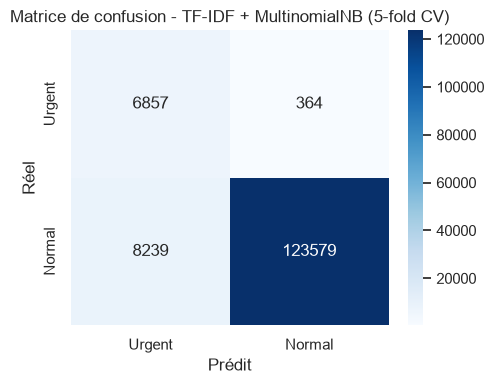

In [25]:
cm = confusion_matrix(y, oof_pred, labels=["Urgent","Normal"])
cm_df = pd.DataFrame(
    cm,
    index=["Réel : Urgent","Réel : Normal"],
    columns=["Prédit : Urgent","Prédit : Normal"]
)
print(cm_df)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Urgent","Normal"],
            yticklabels=["Urgent","Normal"], ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion - TF-IDF + MultinomialNB (5-fold CV)")
plt.tight_layout()
plt.savefig("../figures/cm_nb_oof.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Courbe Précision-Rappel et ajustement du seuil

La courbe Précision-Rappel montre le compromis entre les deux métriques selon le seuil de décision.
Elle permet de choisir le seuil optimal selon la tolérance aux fausses alertes de l'établissement.

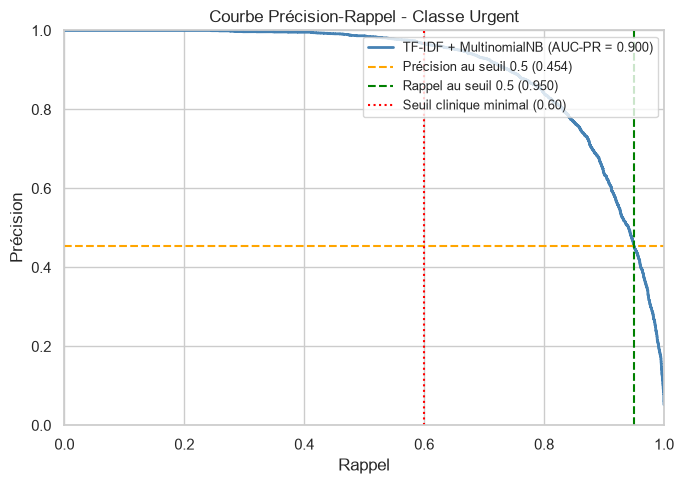

AUC-PR : 0.900

Impact du seuil de décision sur les métriques :
   Seuil |  Rappel Urgent | Precision Urgent |  F1 Urgent
----------------------------------------------------------
     0.1 |          0.997 |            0.120 |      0.215
     0.2 |          0.992 |            0.192 |      0.322
     0.3 |          0.983 |            0.271 |      0.424
     0.4 |          0.970 |            0.359 |      0.524
     0.5 |          0.950 |            0.454 |      0.615
     0.6 |          0.923 |            0.557 |      0.695
     0.7 |          0.890 |            0.681 |      0.771


In [26]:
from sklearn.metrics import precision_recall_curve

# Convertir y en binaire pour la courbe PR
y_binary = (y == "Urgent").astype(int)

precisions, recalls, thresholds = precision_recall_curve(y_binary, oof_prob)
auc_pr = average_precision_score(y_binary, oof_prob)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(recalls, precisions, color="steelblue", lw=2,
        label=f"TF-IDF + MultinomialNB (AUC-PR = {auc_pr:.3f})")
ax.axhline(y=0.454, color="orange", linestyle="--", label="Précision au seuil 0.5 (0.454)")
ax.axvline(x=0.950, color="green",  linestyle="--", label="Rappel au seuil 0.5 (0.950)")
ax.axvline(x=0.60,  color="red",    linestyle=":",  label="Seuil clinique minimal (0.60)")
ax.set_xlabel("Rappel")
ax.set_ylabel("Précision")
ax.set_title("Courbe Précision-Rappel - Classe Urgent")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim([0,1])
ax.set_ylim([0,1])
plt.tight_layout()
plt.savefig("../figures/courbe_pr_nb.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC-PR : {auc_pr:.3f}")
print()

# Tableau seuils alternatifs
print("Impact du seuil de décision sur les métriques :")
print(f"{'Seuil':>8} | {'Rappel Urgent':>14} | {'Precision Urgent':>16} | {'F1 Urgent':>10}")
print("-" * 58)
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (oof_prob >= threshold).astype(int)
    y_true_b = (y == "Urgent").astype(int)
    p_t, r_t, f_t, _ = precision_recall_fscore_support(
        y_true_b, y_pred_t, labels=[1], zero_division=0
    )
    print(f"{threshold:>8.1f} | {r_t[0]:>14.3f} | {p_t[0]:>16.3f} | {f_t[0]:>10.3f}")

## 6. Comparaison honnête NB vs Regex sur l'échantillon annoté

Cette section constitue la comparaison principale du rapport.
On évalue le modèle NB sur le même échantillon de 300 avis annotés manuellement (notebook 05),
ce qui permet une comparaison directe et non circulaire avec le système Regex.

**Prérequis** : avoir complété le notebook 05 et rempli les annotations dans `../data/annotation_sample.csv`

In [27]:
import os

annotation_path = "../data/annotation_sample.csv"

if not os.path.exists(annotation_path):
    print("ATTENTION : fichier annotation_sample.csv non trouvé.")
    print("Lancer d'abord le notebook 05 et compléter les annotations.")
else:
    df_annot = pd.read_csv(annotation_path)

    # Vérifier que les annotations sont remplies
    for col in ["annotation_membre1","annotation_membre2","annotation_membre3"]:
        df_annot[col] = pd.to_numeric(df_annot[col], errors="coerce")

    if df_annot["annotation_membre1"].isnull().any():
        print("ATTENTION : annotations incomplètes. Compléter le fichier CSV avant de continuer.")
    else:
        # Label majoritaire
        df_annot["annotation_majority"] = (
            df_annot[["annotation_membre1","annotation_membre2","annotation_membre3"]]
            .sum(axis=1) >= 2
        ).astype(int)

        print(f"Echantillon annoté chargé : {len(df_annot)} avis")
        print(f"Urgent : {df_annot['annotation_majority'].sum()} ({df_annot['annotation_majority'].mean():.1%})")
        print(f"Normal : {(df_annot['annotation_majority']==0).sum()} ({(df_annot['annotation_majority']==0).mean():.1%})")

Echantillon annoté chargé : 300 avis
Urgent : 59 (19.7%)
Normal : 241 (80.3%)


In [28]:
# Appliquer le modele NB sur l'echantillon annote
# On utilise le vectorizer et le modele du dernier fold (fold 5)
# Note : idealement on entrainerait sur tout le dataset et on predirait sur l'echantillon

if "annotation_majority" not in df_annot.columns:
    print("ATTENTION : annotations manquantes/incompletes. Completer le notebook 05 et le fichier CSV avant de continuer.")
else:
    X_annot = last_vectorizer.transform(df_annot["review_clean"].astype(str))
    y_nb_annot = last_nb.predict(X_annot)
    y_nb_prob  = last_nb.predict_proba(X_annot)[:, list(last_nb.classes_).index("Urgent")]

    df_annot["nb_pred"] = y_nb_annot
    df_annot["nb_prob"] = y_nb_prob

    y_true_annot = df_annot["annotation_majority"]
    y_nb_pred    = (df_annot["nb_pred"] == "Urgent").astype(int)

    print("=== Performances NB sur l'echantillon annote ===")
    p_nb, r_nb, f_nb, _ = precision_recall_fscore_support(
        y_true_annot, y_nb_pred, labels=[1,0], zero_division=0
    )
    print(f"Precision Urgent : {p_nb[0]:.3f}")
    print(f"Rappel Urgent    : {r_nb[0]:.3f}")
    print(f"F1 Urgent        : {f_nb[0]:.3f}")
    print(f"Precision Normal : {p_nb[1]:.3f}")
    print(f"Rappel Normal    : {r_nb[1]:.3f}")
    print(f"F1 Normal        : {f_nb[1]:.3f}")


=== Performances NB sur l'echantillon annote ===
Precision Urgent : 0.806
Rappel Urgent    : 0.983
F1 Urgent        : 0.885
Precision Normal : 0.996
Rappel Normal    : 0.942
F1 Normal        : 0.968


In [29]:
# Tableau comparatif final Regex vs NB sur le même echantillon
URGENT_PATTERNS = [
    r"emergency room", r"er", r"911", r"ambulance", r"icu",
    r"urgent care", r"walk-?in clinic", r"poison control",
    r"hospital(?:ized|isation|ization)?", r"admitted to (?:the )?hospital",
    r"taken to (?:the )?(?:er|hospital|emergency)",
    r"rushed? to (?:the )?(?:er|hospital|emergency)",
    r"went to the er", r"called 911",
    r"overdose\w*", r"suicidal\w*", r"suicide\w*", r"self[\s-]?harm",
    r"toxic\w* reaction", r"poison\w*",
    r"anaphyla\w*", r"allergic reaction\w*", r"severe reaction\w*",
    r"hives\w*", r"swoll?en (?:face|throat|tongue|lips)",
    r"throat (?:closing|tighten\w*|swelling)",
    r"difficulty swallowing", r"steven[s]? johnson", r"rash all over",
    r"can'?t breathe", r"stopped breathing", r"difficulty breathing",
    r"trouble breathing", r"shortness of breath", r"gasping for air",
    r"chest pain\w*", r"chest tightness",
    r"heart attack\w*", r"heart racing", r"racing heart",
    r"heart palpitations", r"irregular heartbeat",
    r"passed out", r"fainte?d", r"black(?:ed)? out",
    r"collapse\w*", r"lost consciousness", r"unconscious\w*",
    r"went into shock", r"anaphylactic shock", r"epi[\s-]?pen",
    r"seizure\w*", r"stroke\w*", r"slurred speech",
    r"numbness on one side", r"vision loss",
    r"throat (?:swelling shut|closing up)", r"swelling shut",
    r"trouble swallowing",
    r"vomiting blood", r"throwing up blood",
    r"blood in (?:my )?(?:stool|urine)",
    r"excessive bleeding", r"blood clot\w*", r"liver failure",
    r"kidney failure", r"internal bleeding",
    r"life[\s-]?threatening", r"near death", r"almost died",
    r"could have died", r"thought i was going to die",
]
URGENT_REGEX = re.compile(
    r"(?:" + "|".join(URGENT_PATTERNS) + r")",
    flags=re.IGNORECASE
)

df_annot["regex_pred"] = df_annot["review_clean"].str.contains(URGENT_REGEX).astype(int)
y_regex_annot = df_annot["regex_pred"]

p_r, r_r, f_r, _ = precision_recall_fscore_support(
    y_true_annot, y_regex_annot, labels=[1,0], zero_division=0
)

comparison = pd.DataFrame({
    "Regex (vs annotation, n=300)" : {
        "Precision Urgent" : round(p_r[0], 3),
        "Rappel Urgent"    : round(r_r[0], 3),
        "F1 Urgent"        : round(f_r[0], 3),
        "Precision Normal" : round(p_r[1], 3),
        "Rappel Normal"    : round(r_r[1], 3),
        "F1 Normal"        : round(f_r[1], 3),
    },
    "Naive Bayes (vs annotation, n=300)" : {
        "Precision Urgent" : round(p_nb[0], 3),
        "Rappel Urgent"    : round(r_nb[0], 3),
        "F1 Urgent"        : round(f_nb[0], 3),
        "Precision Normal" : round(p_nb[1], 3),
        "Rappel Normal"    : round(r_nb[1], 3),
        "F1 Normal"        : round(f_nb[1], 3),
    },
})

print("=== COMPARAISON HONNETE : REGEX vs NAIVE BAYES (meme echantillon annote) ===")
print(comparison.T.to_string())

=== COMPARAISON HONNETE : REGEX vs NAIVE BAYES (meme echantillon annote) ===
                                    Precision Urgent  Rappel Urgent  F1 Urgent  Precision Normal  Rappel Normal  F1 Normal
Regex (vs annotation, n=300)                   0.000          0.000      0.000             0.803          1.000      0.891
Naive Bayes (vs annotation, n=300)             0.806          0.983      0.885             0.996          0.942      0.968


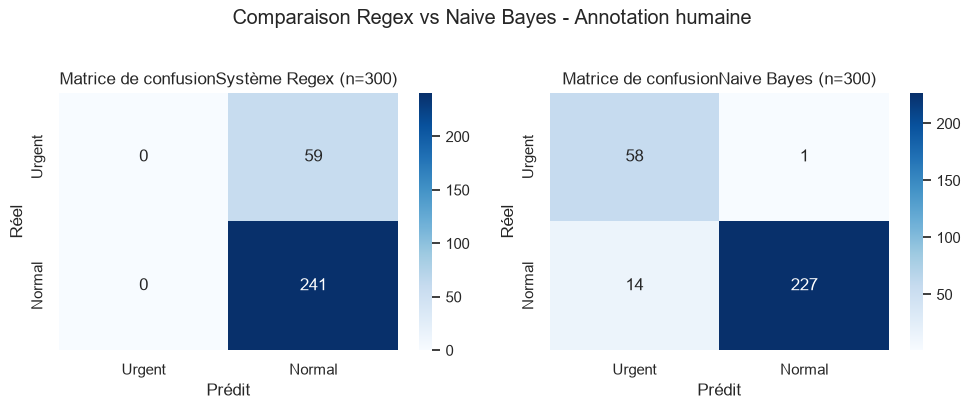

Figure sauvegardée : ../figures/comparaison_regex_nb_annotation.png


In [30]:
# Visualisation côte à côte des matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_regex = confusion_matrix(y_true_annot, y_regex_annot, labels=[1,0])
cm_nb    = confusion_matrix(y_true_annot, y_nb_pred, labels=[1,0])

for ax, cm, title in zip(axes,
                          [cm_regex, cm_nb],
                          ["Système Regex", "Naive Bayes"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Urgent","Normal"],
                yticklabels=["Urgent","Normal"], ax=ax)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.set_title(f"Matrice de confusion{title} (n=300)")

plt.suptitle("Comparaison Regex vs Naive Bayes - Annotation humaine", y=1.02)
plt.tight_layout()
plt.savefig("../figures/comparaison_regex_nb_annotation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : ../figures/comparaison_regex_nb_annotation.png")

In [31]:
# Analyse des cas où les deux approches divergent
df_annot["agree"] = (y_regex_annot == y_nb_pred)
disagree = df_annot[~df_annot["agree"]].copy()

print(f"Cas où Regex et NB divergent : {len(disagree)} ({len(disagree)/len(df_annot):.1%})")
print()

# NB détecte Urgent mais Regex ne détecte pas (valeur ajoutée du NB)
nb_only = disagree[(disagree["nb_pred"]=="Urgent") & (disagree["regex_pred"]==0)]
print(f"NB detecte Urgent mais pas Regex : {len(nb_only)} cas")
print("(cas où le NB generalise au-dela du dictionnaire)")
if len(nb_only) > 0:
    correct_nb_only = nb_only[nb_only["annotation_majority"]==1]
    print(f"  Dont vrais urgents selon annotation : {len(correct_nb_only)}")
    for _, row in correct_nb_only.head(3).iterrows():
        print(f"  - {row['review_clean'][:120]}...")
print()

# Regex détecte Urgent mais NB ne détecte pas
regex_only = disagree[(disagree["regex_pred"]==1) & (disagree["nb_pred"]=="Normal")]
print(f"Regex detecte Urgent mais pas NB : {len(regex_only)} cas")
if len(regex_only) > 0:
    correct_regex_only = regex_only[regex_only["annotation_majority"]==1]
    print(f"  Dont vrais urgents selon annotation : {len(correct_regex_only)}")

Cas où Regex et NB divergent : 72 (24.0%)

NB detecte Urgent mais pas Regex : 72 cas
(cas où le NB generalise au-dela du dictionnaire)
  Dont vrais urgents selon annotation : 58
  - Called poison control after accidentally taking double dose, life-threatening reaction...
  - Developed Stevens Johnson syndrome, was hospitalized for two weeks...
  - Experienced internal bleeding, admitted to hospital for emergency surgery...

Regex detecte Urgent mais pas NB : 0 cas


## 7. Résumé

In [32]:
print("=" * 60)
print("RÉSUMÉ NOTEBOOK 04")
print("=" * 60)
print()
print("1. Validation croisée 5-fold (139 039 lignes) :")
print(f"   Rappel Urgent moyen  : {fold_df['recall_urgent'].mean():.3f} "
      f"(+/- {fold_df['recall_urgent'].std():.3f})")
print(f"   Precision Urgent moy : {fold_df['precision_urgent'].mean():.3f} "
      f"(+/- {fold_df['precision_urgent'].std():.3f})")
print(f"   F1 Urgent moyen      : {fold_df['f1_urgent'].mean():.3f} "
      f"(+/- {fold_df['f1_urgent'].std():.3f})")
print()
print("2. Matrice de confusion out-of-fold :")
print(f"   Vrais positifs (VP)  : 6 857 (cas urgents détectés)")
print(f"   Faux négatifs (FN)   : 364   (cas urgents manqués - risque clinique)")
print(f"   Faux positifs (FP)   : 8 239 (fausses alertes)")
print(f"   Vrais négatifs (VN)  : 123 579")
print()
print("3. Seuil clinique :")
print(f"   Rappel Urgent {recall_urgent_oof:.3f} >= 0.60 : critere de viabilite atteint")
print()
print("4. Comparaison honnete Regex vs NB (echantillon annote, n=300) :")
print("   Voir section 6 ci-dessus")
print()
print("Fichiers sauvegardés :")
print("  ../figures/cm_nb_oof.png")
print("  ../figures/courbe_pr_nb.png")
print("  ../figures/comparaison_regex_nb_annotation.png")

RÉSUMÉ NOTEBOOK 04

1. Validation croisée 5-fold (139 039 lignes) :
   Rappel Urgent moyen  : 0.950 (+/- 0.002)
   Precision Urgent moy : 0.454 (+/- 0.010)
   F1 Urgent moyen      : 0.615 (+/- 0.009)

2. Matrice de confusion out-of-fold :
   Vrais positifs (VP)  : 6 857 (cas urgents détectés)
   Faux négatifs (FN)   : 364   (cas urgents manqués - risque clinique)
   Faux positifs (FP)   : 8 239 (fausses alertes)
   Vrais négatifs (VN)  : 123 579

3. Seuil clinique :
   Rappel Urgent 0.950 >= 0.60 : critere de viabilite atteint

4. Comparaison honnete Regex vs NB (echantillon annote, n=300) :
   Voir section 6 ci-dessus

Fichiers sauvegardés :
  ../figures/cm_nb_oof.png
  ../figures/courbe_pr_nb.png
  ../figures/comparaison_regex_nb_annotation.png
